# Standard SVM - Kidney Stone Risk Prediction Dataset

In [1]:
import time
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,precision_score,recall_score
import pickle, json, os
import warnings; warnings.filterwarnings("ignore")

# Shared metric collector (repository root): logs training accuracy,
# balanced accuracy and AUROC alongside the metrics already tracked below.
import os as _os
import sys as _sys
_REPO_ROOT = _os.path.abspath(_os.path.join('..', '..'))
if _REPO_ROOT not in _sys.path:
    _sys.path.insert(0, _REPO_ROOT)
from metrics_utils import ExtraMetrics


In [2]:
# Common SVM utilities shared across notebooks
from common_svm import StandardSVM, DifferentiallyPrivateSVM, DPSVMOneVsRest


In [3]:
with open("../data/processed_data.pkl","rb") as f: data = pickle.load(f)
X_train=data["X_train"]; X_test=data["X_test"]
y_train=data["y_train"]; y_test=data["y_test"]
feature_names=data["feature_names"]

# DP norm precondition: clip every row to unit L2 norm (||x_i||_2 <= 1).
X_train = X_train / np.maximum(np.linalg.norm(X_train, axis=1, keepdims=True), 1.0)
X_test = X_test / np.maximum(np.linalg.norm(X_test, axis=1, keepdims=True), 1.0)

print(f"Training: {X_train.shape} | Test: {X_test.shape}")

Training: (3200, 23) | Test: (800, 23)


In [4]:
svm = SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42)
print("Training Standard SVM...")
_t0 = time.perf_counter()
svm.fit(X_train, y_train)
train_time = time.perf_counter() - _t0
print("Done!")
# Score the non-private fit on the training partition too, so the
# generalisation gap can be read next to the held-out metrics.
y_train_pred = svm.predict(X_train)


Training Standard SVM...
Done!


In [5]:
y_pred=svm.predict(X_test)
extra = ExtraMetrics()
accuracy=accuracy_score(y_test,y_pred); f1=f1_score(y_test,y_pred,zero_division=0)
extra.add(y_test, y_pred, model=svm, X=X_test, train_true=y_train, train_pred=y_train_pred, train_time=train_time)
precision=precision_score(y_test,y_pred,zero_division=0); recall=recall_score(y_test,y_pred,zero_division=0)
print("="*60)
print("STANDARD SVM - PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}"); print(f"F1-Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}"); print(f"Recall:    {recall:.4f}")
print("="*60)


STANDARD SVM - PERFORMANCE METRICS
Accuracy:  0.9325
F1-Score:  0.9088
Precision: 0.9642
Recall:    0.8594


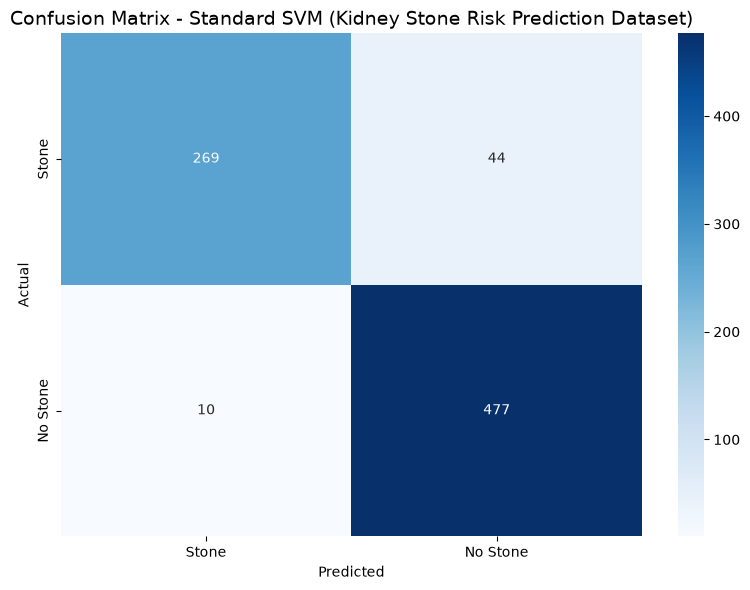

In [6]:
cm=confusion_matrix(y_test,y_pred)
TN,FP,FN,TP=cm[0,0],cm[0,1],cm[1,0],cm[1,1]
custom_cm=np.array([[TP,FN],[FP,TN]])
plt.figure(figsize=(8,6))
sns.heatmap(custom_cm,annot=True,fmt="d",cmap="Blues",xticklabels=["Stone","No Stone"],yticklabels=["Stone","No Stone"])
plt.title("Confusion Matrix - Standard SVM (Kidney Stone Risk Prediction Dataset)",fontsize=14)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.tight_layout(); plt.show()


In [7]:
print("Classification Report:")
print(classification_report(y_test,y_pred,target_names=["No Stone","Stone"]))


Classification Report:
              precision    recall  f1-score   support

    No Stone       0.92      0.98      0.95       487
       Stone       0.96      0.86      0.91       313

    accuracy                           0.93       800
   macro avg       0.94      0.92      0.93       800
weighted avg       0.93      0.93      0.93       800



In [8]:
os.makedirs("output",exist_ok=True)
pd.DataFrame({**{_k: [_v] for _k, _v in extra.means().items()}, "model":["Standard_SVM"],"accuracy":[accuracy],"f1_score":[f1],"precision":[precision],"recall":[recall]}).to_csv("output/baseline_results.csv",index=False)
with open("output/std_svm_report.json","w") as f: json.dump({"model_type":"Standard SVM","dataset":"Kidney Stone Risk Prediction Dataset","parameters":{"kernel":"rbf","C":1.0,"gamma":"scale"},"metrics":{**extra.means(), "accuracy":float(accuracy),"f1_score":float(f1),"precision":float(precision),"recall":float(recall)}},f,indent=4)
print("Baseline saved to output/")

# Export model for MIA
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from model_exporter import export_model
export_model(svm, 'output/model/std_svm_model.pkl')


print("Added metrics:")
print(extra.describe())

Baseline saved to output/


Model successfully exported to output/model/std_svm_model.pkl
Added metrics:
  Train Acc:      0.9534 ± 0.0000
  Balanced Acc:   0.9194 ± 0.0000
  AUROC:          0.9888 ± 0.0000
  Train Time (s): 0.1870 ± 0.0000


In [9]:
print("\n"+"="*60)
print("BASELINE MODEL SUMMARY")
print("="*60)
print(f"Model: Standard SVM (RBF) | Dataset: Kidney Stone Risk Prediction Dataset")
print(f"Accuracy: {accuracy:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
print("="*60)



BASELINE MODEL SUMMARY
Model: Standard SVM (RBF) | Dataset: Kidney Stone Risk Prediction Dataset
Accuracy: 0.9325 | F1: 0.9088 | Precision: 0.9642 | Recall: 0.8594
